## ML Model Training — SMOTE

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import builtins
from google.colab import drive

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
drive.mount('/content/drive')

DRIVE_DATA_PATH = "/content/drive/My Drive/WVS_happiness_study"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!python3 --version

Python 3.12.13


In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.3 MB/s eta 0:00:00


In [ ]:
import warnings
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)


warnings.filterwarnings("ignore")
pd.pandas.set_option("display.max_columns", None)

### Hyperparameter tuning

In [4]:
models = [
    {
        "name": "RandomForest",
        "estimator": RandomForestClassifier(random_state=42),
        "param_grid": {
            "n_estimators": [50, 100, 150],
            "max_depth": [None, 8, 12],
            "min_samples_split": [2, 4, 6],
            "max_features": ['sqrt', 'log2']
        }
    },
    {
        "name": "GradientBoosting",
        "estimator": GradientBoostingClassifier(random_state=42),
        "param_grid": {
            "n_estimators": [50, 100, 150],
            "learning_rate": [0.01, 0.05, 0.1],
            "max_depth": [3, 4, 5]
        }
    },
    {
        "name": "AdaBoost",
        "estimator": AdaBoostClassifier(random_state=42),
        "param_grid": {
            "n_estimators": [50, 100, 150],
            "learning_rate": [0.01, 0.05, 0.1]
        }
    },
    {
        "name": "XGBoost",
        "estimator": XGBClassifier(eval_metric='mlogloss', random_state=42),
        "param_grid": {
            "n_estimators": [50, 100, 150],
            "learning_rate": [0.01, 0.05, 0.1],
            "max_depth": [3, 4, 5]
        }
    },
    {
        "name": "LightGBM",
        "estimator": LGBMClassifier(random_state=42),
        "param_grid": {
            "n_estimators": [50, 100, 150],
            "learning_rate": [0.01, 0.05, 0.1],
            "max_depth": [-1, 5, 8]
        }
    },
    {
        "name": "CatBoost",
        "estimator": CatBoostClassifier(random_state=42, verbose=0),
        "param_grid": {
            "iterations": [100, 200],
            "learning_rate": [0.01, 0.05, 0.1],
            "depth": [3, 5, 7]
        }
    },
    {
        "name": "ExtraTrees",
        "estimator": ExtraTreesClassifier(random_state=42),
        "param_grid": {
            "n_estimators": [50, 100, 150],
            "max_depth": [None, 8, 12],
            "min_samples_split": [2, 4, 6],
            "max_features": ['sqrt', 'log2']
        }
    }
]


In [5]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, matthews_corrcoef
import pandas as pd
import inspect

def train_ensemble_models(X_train, y_train, X_val, y_val, X_test, y_test, models):
    """
    Train, tune, and evaluate ensemble models on preprocessed data.

    Parameters:
    -----------
    X_train, X_val, X_test : preprocessed feature arrays
    y_train, y_val, y_test : target arrays/Series
    models : list of dicts
        Each dict should contain:
            - 'name': str, model name
            - 'estimator': sklearn-compatible classifier
            - 'param_grid': dict of hyperparameters for GridSearchCV

    Returns:
    --------
    results_df : pd.DataFrame
        Sorted results of models by Test Accuracy
    best_models : dict
        Best model per algorithm keyed by model name
    """

    # Helper function to ensure y is 1-D
    def flatten_y(y):
        # Get the variable name from the caller's local variables
        callers_local_vars = inspect.currentframe().f_back.f_locals.items()
        var_names = [name for name, val in callers_local_vars if val is y]
        var_name = var_names[0] if var_names else "y"

        if isinstance(y, pd.DataFrame):
            if y.shape[1] == 1:
                print(f"{var_name}: Converted to 1D pd automatically...")
                return y.iloc[:, 0]
            else:
                raise ValueError(f"{var_name} has multiple columns ({y.shape[1]}), cannot flatten automatically")
        elif isinstance(y, pd.Series):
            print(f"{var_name}: Already 1D pd.Series")
            return y
        elif isinstance(y, (np.ndarray, list)):
            print(f"{var_name}: Converted to 1D np automatically...")
            return np.array(y).ravel()
        else:
            raise TypeError(f"{var_name}: Unsupported y type: {type(y)}")

    # Flatten targets
    y_train = flatten_y(y_train)
    y_test  = flatten_y(y_test)
    y_val   = flatten_y(y_val)

    results = []
    best_models = {}

    for m in models:
        print(f"\nTraining {m['name']}...")
        grid = GridSearchCV(
            estimator=m['estimator'],
            param_grid=m['param_grid'],
            cv=5,
            scoring='accuracy',
            n_jobs=-1
        )
        grid.fit(X_train, y_train)

        # Evaluate
        y_val_pred = grid.predict(X_val)
        val_acc = accuracy_score(y_val, y_val_pred)

        y_test_pred = grid.predict(X_test)
        test_acc = accuracy_score(y_test, y_test_pred)

        y_val_mcc = matthews_corrcoef(y_val, y_val_pred)
        y_test_mcc = matthews_corrcoef(y_test, y_test_pred)

        results.append({
            "Model": m["name"],
            "Best Params": grid.best_params_,
            "Validation Accuracy": val_acc,
            "Test Accuracy": test_acc,
            "Validation MCC": y_val_mcc,
            "Test MCC": y_test_mcc
        })

        best_models[m["name"]] = {
            "model": grid.best_estimator_,
            "test_accuracy": test_acc
        }

    results_df = pd.DataFrame(results).sort_values(by="Validation Accuracy", ascending=False)
    return results_df, best_models


### Load the train, test & val sets.

In [2]:
X_train_final = pd.read_csv(f'{DRIVE_DATA_PATH}/data/train_sets/X_train_final_smote.csv')
X_test_final = pd.read_csv(f'{DRIVE_DATA_PATH}/data/test_sets/X_test_final.csv')
X_val_final = pd.read_csv(f'{DRIVE_DATA_PATH}/data/val_sets/X_val_final.csv')

y_train_final = pd.read_csv(f'{DRIVE_DATA_PATH}/data/train_sets/y_train_final_smote.csv')
y_test_final = pd.read_csv(f'{DRIVE_DATA_PATH}/data/test_sets/y_test_final.csv')
y_val_final = pd.read_csv(f'{DRIVE_DATA_PATH}/data/val_sets/y_val_final.csv')

In [7]:
# Show results sorted by TRAIN accuracy (descending)
results_df, best_models = train_ensemble_models(X_train_final, y_train_final,
                                                X_val_final, y_val_final, X_test_final,
                                                y_test_final, models)
print(results_df.to_string(index=False))

y_train: Converted to 1D pd automatically...
y_test: Converted to 1D pd automatically...
y_val: Converted to 1D pd automatically...

Training RandomForest...

Training GradientBoosting...

Training AdaBoost...

Training XGBoost...

Training LightGBM...
[LightGBM] [Info] Number of positive: 56869, number of negative: 56869
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.096998 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 17850
[LightGBM] [Info] Number of data points in the train set: 113738, number of used features: 70
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warni

In [8]:
# Get the overall best model (highest validation accuracy)
overall_best_model_name = results_df.iloc[0]["Model"]
overall_best_model = best_models[overall_best_model_name]["model"]
print(f"\nBest Model: {overall_best_model_name} (Test Accuracy: {results_df.iloc[0]['Test Accuracy']:.4f})")


Best Model: LightGBM (Test Accuracy: 0.8779)


### Model Evaluation

Accuracy: 0.8778894119300218
Precision (macro): 0.7766084640652464
Recall (macro): 0.642171609556872
F1 Score (macro): 0.6773473665120561


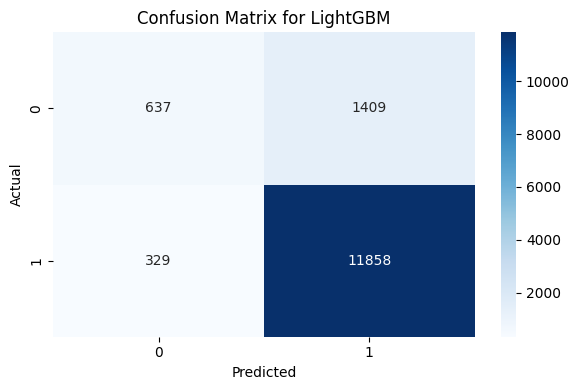


Classification Report:
               precision    recall  f1-score   support

           0     0.6594    0.3113    0.4230      2046
           1     0.8938    0.9730    0.9317     12187

    accuracy                         0.8779     14233
   macro avg     0.7766    0.6422    0.6773     14233
weighted avg     0.8601    0.8779    0.8586     14233



In [9]:
# Predict on test set
y_pred = overall_best_model.predict(X_test_final)

# Print evaluation metrics
print("Accuracy:", accuracy_score(y_test_final, y_pred))
print("Precision (macro):", precision_score(y_test_final, y_pred, average='macro'))
print("Recall (macro):", recall_score(y_test_final, y_pred, average='macro'))
print("F1 Score (macro):", f1_score(y_test_final, y_pred, average='macro'))

# Confusion Matrix
cm = confusion_matrix(y_test_final, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f"Confusion Matrix for {overall_best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# Classification Report
print("\nClassification Report:\n", classification_report(y_test_final, y_pred, digits=4))

#### Export Model

In [10]:
import pickle
# Save model
final_model = overall_best_model
with open(f"{DRIVE_DATA_PATH}/data/model_latest_smote.pkl", "wb") as f:
    pickle.dump(final_model, f)